In [663]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [664]:
df=pd.read_csv(r"D:\AI ECHO\givendata.csv")
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No


In [665]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               500 non-null    object
 1   title              500 non-null    object
 2   review             500 non-null    object
 3   rating             500 non-null    int64 
 4   username           500 non-null    object
 5   helpful_votes      500 non-null    int64 
 6   review_length      500 non-null    int64 
 7   platform           500 non-null    object
 8   language           500 non-null    object
 9   location           500 non-null    object
 10  version            500 non-null    object
 11  verified_purchase  500 non-null    object
dtypes: int64(3), object(9)
memory usage: 47.0+ KB


In [666]:
df.shape

(500, 12)

In [667]:
df.isnull().sum()

date                 0
title                0
review               0
rating               0
username             0
helpful_votes        0
review_length        0
platform             0
language             0
location             0
version              0
verified_purchase    0
dtype: int64

In [668]:
df.columns

Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase'],
      dtype='object')

In [669]:
df[['review']].head(10)

,review
0,"Not satisfied, many bugs and issues."
1,Amazing quality and user-friendly interface.
2,"Terrible experience, needs major improvements."
3,Poor performance and not user-friendly.
4,"Not satisfied, many bugs and issues."
5,"Waste of time, does not meet expectations."
6,"Highly satisfied, the app works exactly as exp..."
7,"Highly satisfied, the app works exactly as exp..."
8,"Excellent app, very easy to use and extremely ..."
9,"Great experience, smooth performance and usefu..."


In [670]:
df = df.dropna(subset=['review'])

In [671]:
df=df.drop(columns=['date'])

In [672]:
df.head()

,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No


In [673]:
df.shape

(500, 11)

In [674]:
def get_sentiment(rating):
    rating = int(rating)
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(get_sentiment)

In [675]:
df['sentiment'].value_counts()

sentiment
Positive    200
Negative    195
Neutral     105
Name: count, dtype: int64

In [676]:
df

,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,sentiment
0,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No,Negative
1,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No,Positive
2,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No,Negative
3,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes,Negative
4,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...
495,Review title 496,"Waste of time, does not meet expectations.",2,user496,81,7,Flipkart,ja,Qatar,1.2.3,No,Negative
496,Review title 497,"Great experience, smooth performance and usefu...",5,user497,48,7,Google Play,fr,Nepal,2.1.4,No,Positive
497,Review title 498,"Terrible experience, needs major improvements.",2,user498,16,5,Google Play,de,Poland,2.1.4,Yes,Negative
498,Review title 499,"Highly satisfied, the app works exactly as exp...",4,user499,68,8,Google Play,zh,Nepal,1.2.3,Yes,Positive


In [677]:
df.to_csv("df_1.csv", index=False)

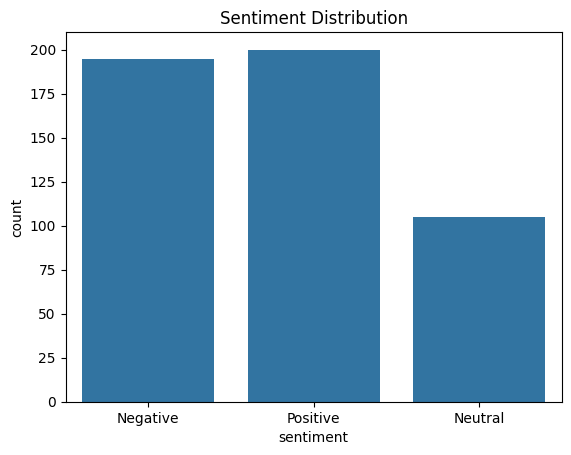

In [678]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

**Things to check**

1. 📊 What is the distribution of review ratings?
2. 👍👎 How many reviews were marked as helpful (above a certain threshold)?
3. 🧭 What are the most common keywords in positive vs. negative reviews?
4. 📆 How has the average rating changed over time?
5. 🌍 How do ratings vary by user location?
6. 🧑‍💻 Which platform (Web vs Mobile) gets better reviews?
7. ✅❌ 7. Are verified users more satisfied than non-verified ones?
8. 🔠 8. What’s the average length of reviews per rating category?
9. 💬 9. What are the most mentioned words in 1-star reviews?
10. 📱🧪 10. What ChatGPT version received the highest average rating?



In [679]:
#1 What is the distribution of review ratings?
# Bar plot

fig1 = px.histogram(df, x='rating', title='Distribution of Review Ratings', color='rating')

fig1.update_layout(
    width = 700,
    height = 500,
    xaxis_title='Rating',
    yaxis_title='Count',
    bargap=0.2,
    bargroupgap=0.1
)
fig1.update_layout(
    title_font=dict(color='#FF6F61', size=22),  # Title color
    xaxis_title=dict(font = dict(color='#999999', size=17)),
    yaxis_title=dict(font = dict(color='#999999', size=17)),
    template="plotly_dark")
fig1.show()

In [680]:
# 2.How many reviews were marked as helpful (above a certain threshold)?
# Pie chart

threshold = 10

df['is_helpful'] = df['helpful_votes'].apply(lambda x: '👍 Helpful' if x > threshold else '👎 Not Helpful')

fig2 = px.pie(df, names='is_helpful', title='👍 Helpful vs 👎 Not Helpful Reviews',)

fig2.update_traces(
    textposition='inside',
    textinfo='percent+label',
    hole=.2)

fig2.update_layout(
    width = 700,
    height = 500,
    xaxis_title=dict(font = dict(size=17)),
    yaxis_title=dict(font = dict(size=17)),
    title_font=dict(color='#E0E0E0', size=22), # Title color
    template="plotly_dark")
fig2.show()

In [681]:
# 3. What are the most common keywords in positive vs. negative reviews?

# word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

review_df_positive = df[df['rating'] >= 4]
review_df_negative = df[df['rating'] <= 2]

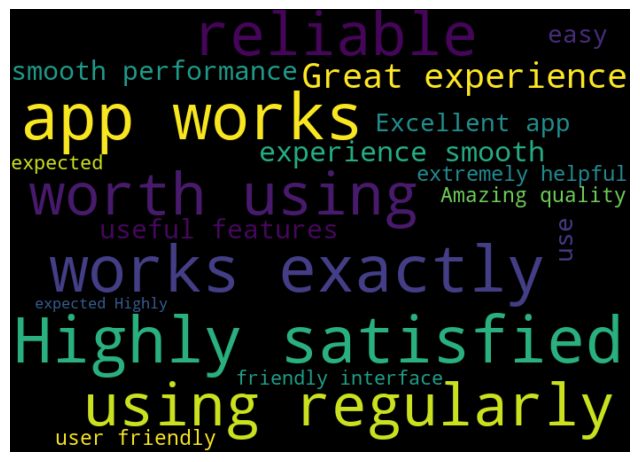

In [682]:
# Positive reviews
all_words = ' '.join([text for text in review_df_positive['review']])
wordcolud = WordCloud(width=700, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(8, 6))
plt.imshow(wordcolud, interpolation="bilinear")
plt.axis('off')
plt.show()

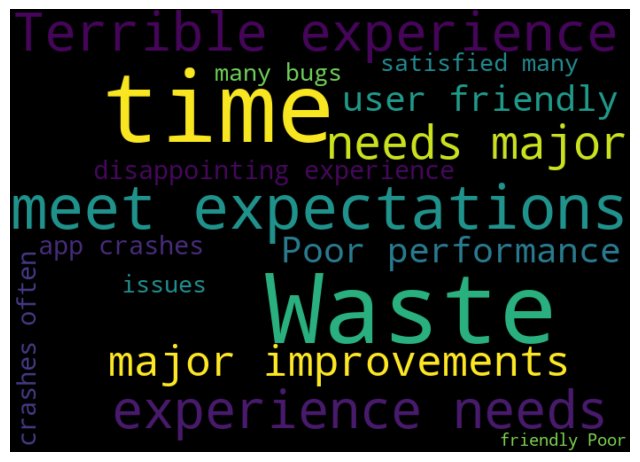

In [683]:
# Negative reviews
all_words = ' '.join([text for text in review_df_negative['review']])
wordcolud = WordCloud(width=700, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(8, 6))
plt.imshow(wordcolud, interpolation="bilinear")
plt.axis('off')
plt.show()

In [684]:
# 5. How do ratings vary by user location?

country_df = df.groupby('location')['rating'].mean().reset_index()

fig = px.choropleth(
    country_df,
    locations='location',          # column with country names
    locationmode='country names',  # use country names instead of ISO codes
    color='rating',                # numeric column to color by
    hover_name='location',         # label on hover
    color_continuous_scale='Tealrose',  # nice gradient
    title='Average Rating by Country'
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth',
        bgcolor='#0E1117'
    ),
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    paper_bgcolor='#0E1117',
    plot_bgcolor='#0E1117',
    font=dict(color='white', size=14),
    margin=dict(t=90, b=30, l=20, r=20)
)

fig.update_coloraxes(
    colorbar_title='Average Rating',
    colorbar_title_font=dict(size=16, color='white'),
    colorbar_tickfont=dict(size=12, color='white')
)

fig.show()


In [685]:
# 6. Which platform gets better reviews?

platform_df = df.groupby('rating')['platform'].value_counts().reset_index(name='count')
platform_df

fig = px.bar(
    platform_df,
    x='platform',
    y='count',
    color='rating',
    title='Average Rating by Platform',
    barmode='stack'
)

fig.update_layout(
    width = 700,
    height = 500,
    xaxis_title='Platform',
    yaxis_title='Average Rating',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

In [686]:
# 7. Are verified users more satisfied than non-verified ones?

verified_df = df.groupby('rating')['verified_purchase'].value_counts().reset_index(name='count')

fig = px.bar(
    verified_df,
    x='verified_purchase',
    y='count',
    color='rating',
    title='Average Rating by Verified Purchase',
    barmode='stack'
)

fig.update_layout(
    width = 700,
    height = 500,
    xaxis_title='Verified Purchase',
    yaxis_title='Average Rating',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

In [687]:
# 8. What’s the average length of reviews per rating category?

df['review_length'] = df['review'].apply(lambda x: len(x.split()))
avg_review_length = df.groupby('rating')['review_length'].mean()
# avg_review_length

fig = px.bar(
    avg_review_length,
    x=avg_review_length.index,
    y=avg_review_length.values,
    color=avg_review_length.values,
    title='Average Review Length by Rating'
)

fig.update_layout(
    width = 700,
    height = 500,
    xaxis_title='Rating',
    yaxis_title='Average Review Length',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

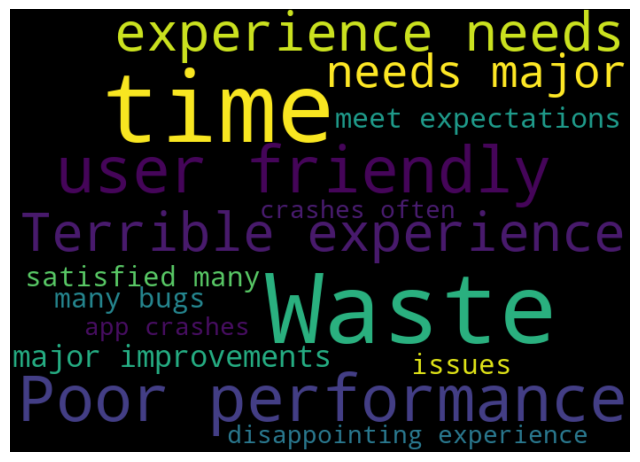

In [688]:
# 9. What are the most mentioned words in 1-star reviews?

review_df_1star = df[df['rating'] < 2]


# N1 Star reviews
all_words = ' '.join([text for text in review_df_1star['review']])
wordcolud = WordCloud(width=700, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(8, 6))
plt.imshow(wordcolud, interpolation="bilinear")
plt.axis('off')
plt.show()

In [689]:
# 10. What ChatGPT version received the highest average rating?

version_avg_rating = df.groupby('version')['rating'].mean().reset_index()

fig = px.bar(
    version_avg_rating,
    x='version',
    y='rating',
    color='rating',
    title='Average Rating by ChatGPT Version',
    barmode='stack'
)

fig.update_layout(
    width = 3000,
    height = 500,
    xaxis_title='ChatGPT Version',
    yaxis_title='Average Rating',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

In [690]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [691]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [692]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'\d+', '', text)              # remove numbers
    text = re.sub(r'[^a-z\s]', '', text)         # remove symbols
    
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(words)

In [693]:
df['clean_review'] = df['review'].apply(clean_text)

In [694]:
df[['review', 'clean_review']].head()

,review,clean_review
0,"Not satisfied, many bugs and issues.",satisfied many bug issue
1,Amazing quality and user-friendly interface.,amazing quality userfriendly interface
2,"Terrible experience, needs major improvements.",terrible experience need major improvement
3,Poor performance and not user-friendly.,poor performance userfriendly
4,"Not satisfied, many bugs and issues.",satisfied many bug issue


In [695]:
df = df.drop_duplicates(subset=['clean_review'])
print(df.shape)

(15, 14)


In [696]:
from sklearn.model_selection import train_test_split

X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [697]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [698]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [699]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.3333333333333333


In [700]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

Classification Report:

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
     Neutral       0.50      1.00      0.67         1
    Positive       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.17      0.33      0.22         3
weighted avg       0.17      0.33      0.22         3



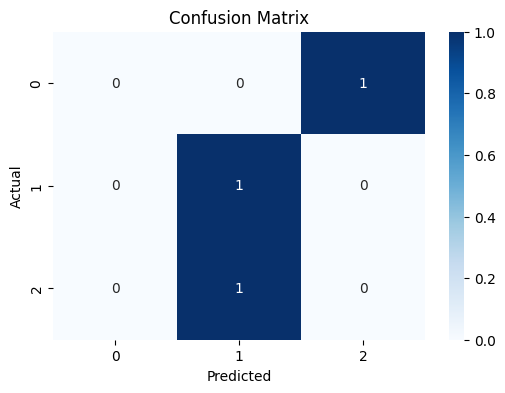

In [701]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [702]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred_nb = model.predict(X_test)

In [703]:
from sklearn.metrics import accuracy_score

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.0


In [704]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))


Classification Report:

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       1.0
     Neutral       0.00      0.00      0.00       1.0
    Positive       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



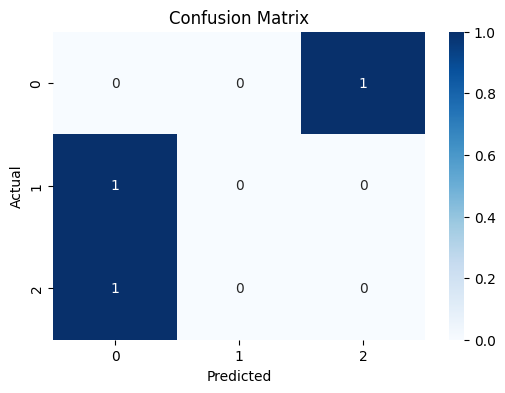

In [705]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [706]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Naive Bayes Accuracy: 0.0
Logistic Regression Accuracy: 0.3333333333333333


“Two machine learning models, Logistic Regression and Naïve Bayes, were trained for sentiment classification. Logistic Regression performed better in terms of accuracy and overall evaluation metrics. Therefore, it was selected as the final model for deployment.”

In [707]:
import pickle

# Save model
pickle.dump(lr_model, open("sentiment_model.pkl", "wb"))

# Save vectorizer
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))